In [1]:
import json
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from IPython.display import display
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)


def find_project_root(start_path: Path) -> Path:
    """Find the project root containing src/config.py."""
    current_path = start_path.resolve()

    for candidate in [current_path, *current_path.parents]:
        if (candidate / "src" / "config.py").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root containing src/config.py."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR

PROCESSED_DIR = Path(PROCESSED_DATA_DIR)
MODEL_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"

FEATURE_FILE = PROCESSED_DIR / "audio_features.csv"

SELECTED_MODEL_FILE = (
    MODEL_DIR / "music_genre_ml.joblib"
)

MODEL_METADATA_FILE = (
    MODEL_DIR / "music_genre_ml_metadata.json"
)

FINAL_MODEL_FILE = (
    MODEL_DIR / "music_genre_ml_final.joblib"
)

FINAL_METADATA_FILE = (
    MODEL_DIR / "music_genre_ml_final_metadata.json"
)

TEST_REPORT_FILE = (
    REPORT_DIR / "ml_test_classification_report.txt"
)

TEST_REPORT_CSV = (
    REPORT_DIR / "ml_test_classification_report.csv"
)

TEST_PREDICTIONS_FILE = (
    REPORT_DIR / "ml_test_predictions.csv"
)

TEST_CONFUSION_MATRIX_FILE = (
    FIGURE_DIR / "ml_test_confusion_matrix.png"
)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.executable)
print("Scikit-learn:", sklearn.__version__)
print("Feature file exists:", FEATURE_FILE.exists())
print("Selected model exists:", SELECTED_MODEL_FILE.exists())
print("Metadata exists:", MODEL_METADATA_FILE.exists())

if ".venv" not in sys.executable:
    raise RuntimeError(
        "Select the Music Genre Classification AI (.venv) kernel."
    )

required_files = [
    FEATURE_FILE,
    SELECTED_MODEL_FILE,
    MODEL_METADATA_FILE,
]

missing_files = [
    str(path)
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        f"Required files are missing: {missing_files}"
    )

Python: d:\Projects\music-genre-classification-AI\.venv\Scripts\python.exe
Scikit-learn: 1.9.0
Feature file exists: True
Selected model exists: True
Metadata exists: True


In [2]:
model_metadata = json.loads(
    MODEL_METADATA_FILE.read_text(
        encoding="utf-8"
    )
)

selected_model_name = model_metadata["model_name"]
feature_columns = model_metadata["feature_columns"]
genre_labels = model_metadata["genre_labels"]

print("Selected model:", selected_model_name)
print("Number of features:", len(feature_columns))
print("Genre labels:", genre_labels)
print(
    "Validation Macro F1:",
    model_metadata["validation_f1_macro"],
)

Selected model: Support Vector Machine
Number of features: 90
Genre labels: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Validation Macro F1: 0.8256412275700047


In [3]:
feature_df = pd.read_csv(FEATURE_FILE)

required_columns = {
    "file_path",
    "filename",
    "genre",
    "split",
}

missing_columns = (
    required_columns - set(feature_df.columns)
)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

missing_feature_columns = [
    column
    for column in feature_columns
    if column not in feature_df.columns
]

if missing_feature_columns:
    raise ValueError(
        "Feature columns used during training are missing: "
        f"{missing_feature_columns[:10]}"
    )

feature_df[feature_columns] = (
    feature_df[feature_columns]
    .replace([np.inf, -np.inf], np.nan)
)

invalid_rows = (
    feature_df[feature_columns]
    .isna()
    .any(axis=1)
)

if invalid_rows.any():
    print(
        "Removing invalid rows:",
        int(invalid_rows.sum()),
    )

    feature_df = (
        feature_df.loc[~invalid_rows]
        .reset_index(drop=True)
    )

print("Total usable rows:", len(feature_df))

display(
    feature_df["split"]
    .value_counts()
    .reindex(["train", "validation", "test"])
    .rename("track_count")
    .to_frame()
)

Total usable rows: 999


,track_count
split,
train,699
validation,150
test,150


In [4]:
development_df = feature_df[
    feature_df["split"].isin(
        ["train", "validation"]
    )
].copy()

test_df = feature_df[
    feature_df["split"] == "test"
].copy()

if development_df.empty:
    raise ValueError(
        "Training and validation data are empty."
    )

if test_df.empty:
    raise ValueError(
        "Test data is empty."
    )

X_development = development_df[feature_columns]
y_development = development_df["genre"]

X_test = test_df[feature_columns]
y_test = test_df["genre"]

print(
    "Development shape:",
    X_development.shape,
)

print(
    "Test shape:",
    X_test.shape,
)

print("\nDevelopment genre distribution:")

display(
    y_development
    .value_counts()
    .sort_index()
    .rename("track_count")
    .to_frame()
)

print("\nTest genre distribution:")

display(
    y_test
    .value_counts()
    .sort_index()
    .rename("track_count")
    .to_frame()
)

Development shape: (849, 90)
Test shape: (150, 90)

Development genre distribution:


,track_count
genre,
blues,85
classical,85
country,85
disco,85
hiphop,85
jazz,84
metal,85
pop,85
reggae,85



Test genre distribution:


,track_count
genre,
blues,15
classical,15
country,15
disco,15
hiphop,15
jazz,15
metal,15
pop,15
reggae,15


In [5]:
selected_model = joblib.load(
    SELECTED_MODEL_FILE
)

final_model = clone(
    selected_model
)

print("Original selected model:")
print(selected_model)

print("\nFresh cloned model:")
print(final_model)

Original selected model:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SVC(C=10.0, probability=True, random_state=42))])

Fresh cloned model:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SVC(C=10.0, probability=True, random_state=42))])


In [6]:
print(
    f"Training final {selected_model_name} model..."
)

training_start = time.perf_counter()

final_model.fit(
    X_development,
    y_development,
)

final_training_seconds = (
    time.perf_counter() - training_start
)

print("Final model training completed.")
print(
    f"Training time: {final_training_seconds:.2f} seconds"
)

Training final Support Vector Machine model...
Final model training completed.
Training time: 0.27 seconds


d:\Projects\music-genre-classification-AI\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [7]:
prediction_start = time.perf_counter()

test_predictions = final_model.predict(
    X_test
)

prediction_seconds = (
    time.perf_counter() - prediction_start
)

print(
    f"Predicted {len(test_predictions)} tracks "
    f"in {prediction_seconds:.4f} seconds"
)

print(
    "Average prediction time per track:",
    f"{prediction_seconds / len(test_predictions):.6f} seconds",
)

Predicted 150 tracks in 0.0364 seconds
Average prediction time per track: 0.000242 seconds


In [8]:
test_accuracy = accuracy_score(
    y_test,
    test_predictions,
)

test_precision_macro = precision_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0,
)

test_recall_macro = recall_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0,
)

test_f1_macro = f1_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0,
)

test_f1_weighted = f1_score(
    y_test,
    test_predictions,
    average="weighted",
    zero_division=0,
)

final_metrics_df = pd.DataFrame(
    [
        {
            "model": selected_model_name,
            "test_accuracy": test_accuracy,
            "test_precision_macro": test_precision_macro,
            "test_recall_macro": test_recall_macro,
            "test_f1_macro": test_f1_macro,
            "test_f1_weighted": test_f1_weighted,
            "training_seconds": final_training_seconds,
            "prediction_seconds": prediction_seconds,
        }
    ]
)

display(
    final_metrics_df.style.format(
        {
            "test_accuracy": "{:.4f}",
            "test_precision_macro": "{:.4f}",
            "test_recall_macro": "{:.4f}",
            "test_f1_macro": "{:.4f}",
            "test_f1_weighted": "{:.4f}",
            "training_seconds": "{:.2f}",
            "prediction_seconds": "{:.4f}",
        }
    )
)

,model,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted,training_seconds,prediction_seconds
0,Support Vector Machine,0.8200,0.8278,0.8200,0.8157,0.8157,0.27,0.0364


In [9]:
test_report_text = classification_report(
    y_test,
    test_predictions,
    labels=genre_labels,
    target_names=genre_labels,
    digits=4,
    zero_division=0,
)

print(
    f"Final Test Classification Report "
    f"— {selected_model_name}\n"
)

print(test_report_text)

TEST_REPORT_FILE.write_text(
    (
        f"Final model: {selected_model_name}\n"
        f"Development samples: {len(X_development)}\n"
        f"Test samples: {len(X_test)}\n\n"
        f"{test_report_text}"
    ),
    encoding="utf-8",
)

print("\nReport saved to:")
print(TEST_REPORT_FILE)

Final Test Classification Report — Support Vector Machine

              precision    recall  f1-score   support

       blues     0.8750    0.9333    0.9032        15
   classical     0.9286    0.8667    0.8966        15
     country     0.6842    0.8667    0.7647        15
       disco     0.8889    0.5333    0.6667        15
      hiphop     0.7333    0.7333    0.7333        15
        jazz     0.8333    1.0000    0.9091        15
       metal     0.8667    0.8667    0.8667        15
         pop     0.7778    0.9333    0.8485        15
      reggae     0.8571    0.8000    0.8276        15
        rock     0.8333    0.6667    0.7407        15

    accuracy                         0.8200       150
   macro avg     0.8278    0.8200    0.8157       150
weighted avg     0.8278    0.8200    0.8157       150


Report saved to:
D:\Projects\music-genre-classification-AI\reports\ml_test_classification_report.txt


In [10]:
test_report_dictionary = classification_report(
    y_test,
    test_predictions,
    labels=genre_labels,
    target_names=genre_labels,
    output_dict=True,
    zero_division=0,
)

test_report_df = (
    pd.DataFrame(test_report_dictionary)
    .transpose()
)

test_report_df.to_csv(
    TEST_REPORT_CSV,
    index=True,
)

display(test_report_df)

print("CSV report saved to:")
print(TEST_REPORT_CSV)

,precision,recall,f1-score,support
blues,0.875000,0.933333,0.903226,15.00
classical,0.928571,0.866667,0.896552,15.00
country,0.684211,0.866667,0.764706,15.00
disco,0.888889,0.533333,0.666667,15.00
hiphop,0.733333,0.733333,0.733333,15.00
jazz,0.833333,1.000000,0.909091,15.00
metal,0.866667,0.866667,0.866667,15.00
pop,0.777778,0.933333,0.848485,15.00
reggae,0.857143,0.800000,0.827586,15.00
rock,0.833333,0.666667,0.740741,15.00


CSV report saved to:
D:\Projects\music-genre-classification-AI\reports\ml_test_classification_report.csv


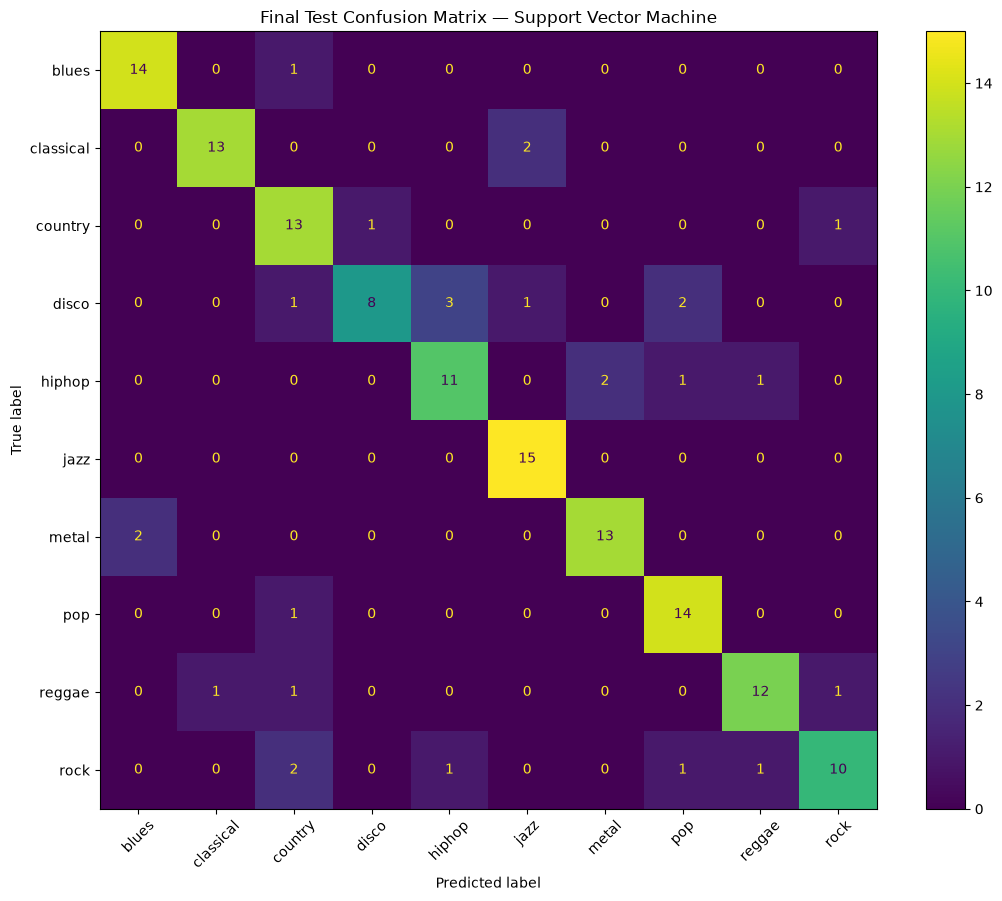

Confusion matrix saved to:
D:\Projects\music-genre-classification-AI\reports\figures\ml_test_confusion_matrix.png


In [11]:
figure, axis = plt.subplots(
    figsize=(11, 9)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=genre_labels,
    display_labels=genre_labels,
    xticks_rotation=45,
    values_format="d",
    ax=axis,
)

axis.set_title(
    f"Final Test Confusion Matrix — "
    f"{selected_model_name}"
)

figure.tight_layout()

figure.savefig(
    TEST_CONFUSION_MATRIX_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Confusion matrix saved to:")
print(TEST_CONFUSION_MATRIX_FILE)

In [12]:
prediction_df = test_df[
    [
        "file_path",
        "filename",
        "genre",
    ]
].copy()

prediction_df = prediction_df.rename(
    columns={
        "genre": "actual_genre",
    }
)

prediction_df["predicted_genre"] = (
    test_predictions
)

prediction_df["correct"] = (
    prediction_df["actual_genre"]
    == prediction_df["predicted_genre"]
)

display(prediction_df.head())

print(
    "Correct predictions:",
    int(prediction_df["correct"].sum()),
)

print(
    "Incorrect predictions:",
    int((~prediction_df["correct"]).sum()),
)

,file_path,filename,actual_genre,predicted_genre,correct
6,data\raw\genres_original\disco\disco.00021.wav,disco.00021.wav,disco,pop,False
10,data\raw\genres_original\metal\metal.00019.wav,metal.00019.wav,metal,metal,True
12,data\raw\genres_original\country\country.00094...,country.00094.wav,country,country,True
22,data\raw\genres_original\classical\classical.0...,classical.00008.wav,classical,classical,True
23,data\raw\genres_original\blues\blues.00021.wav,blues.00021.wav,blues,blues,True


Correct predictions: 123
Incorrect predictions: 27


In [13]:
if hasattr(final_model, "predict_proba"):
    probabilities = final_model.predict_proba(
        X_test
    )

    model_classes = list(
        final_model.classes_
    )

    prediction_df["confidence"] = (
        probabilities.max(axis=1)
    )

    for class_index, genre in enumerate(
        model_classes
    ):
        prediction_df[
            f"probability_{genre}"
        ] = probabilities[:, class_index]

    print(
        "Confidence scores added successfully."
    )

else:
    prediction_df["confidence"] = np.nan

    print(
        "The selected model does not support "
        "probability predictions."
    )

display(
    prediction_df[
        [
            "filename",
            "actual_genre",
            "predicted_genre",
            "correct",
            "confidence",
        ]
    ].head(10)
)

Confidence scores added successfully.


,filename,actual_genre,predicted_genre,correct,confidence
6,disco.00021.wav,disco,pop,False,0.577118
10,metal.00019.wav,metal,metal,True,0.942141
12,country.00094.wav,country,country,True,0.834199
22,classical.00008.wav,classical,classical,True,0.990471
23,blues.00021.wav,blues,blues,True,0.956485
24,hiphop.00066.wav,hiphop,hiphop,True,0.882746
42,reggae.00020.wav,reggae,reggae,True,0.943355
49,blues.00082.wav,blues,country,False,0.724046
52,pop.00052.wav,pop,pop,True,0.915963
62,country.00079.wav,country,country,True,0.843944


In [14]:
incorrect_predictions_df = (
    prediction_df.loc[
        ~prediction_df["correct"]
    ]
    .sort_values(
        by="confidence",
        ascending=False,
    )
)

print(
    "Incorrect predictions:",
    len(incorrect_predictions_df),
)

display(
    incorrect_predictions_df[
        [
            "filename",
            "actual_genre",
            "predicted_genre",
            "confidence",
        ]
    ].head(20)
)

Incorrect predictions: 27


,filename,actual_genre,predicted_genre,confidence
327,disco.00085.wav,disco,hiphop,0.937858
227,disco.00063.wav,disco,hiphop,0.896622
384,hiphop.00060.wav,hiphop,reggae,0.826544
793,disco.00027.wav,disco,hiphop,0.815686
800,classical.00062.wav,classical,jazz,0.727644
49,blues.00082.wav,blues,country,0.724046
521,hiphop.00095.wav,hiphop,metal,0.663519
560,rock.00099.wav,rock,country,0.637613
719,disco.00020.wav,disco,country,0.623720
756,country.00043.wav,country,rock,0.594287


In [15]:
prediction_df.to_csv(
    TEST_PREDICTIONS_FILE,
    index=False,
)

print("Test predictions saved to:")
print(TEST_PREDICTIONS_FILE)

Test predictions saved to:
D:\Projects\music-genre-classification-AI\reports\ml_test_predictions.csv


In [16]:
joblib.dump(
    final_model,
    FINAL_MODEL_FILE,
)

final_metadata = {
    "model_name": selected_model_name,
    "model_file": FINAL_MODEL_FILE.name,
    "feature_columns": feature_columns,
    "genre_labels": genre_labels,
    "training_splits": [
        "train",
        "validation",
    ],
    "test_split": "test",
    "development_samples": int(
        len(X_development)
    ),
    "test_samples": int(
        len(X_test)
    ),
    "test_accuracy": float(
        test_accuracy
    ),
    "test_precision_macro": float(
        test_precision_macro
    ),
    "test_recall_macro": float(
        test_recall_macro
    ),
    "test_f1_macro": float(
        test_f1_macro
    ),
    "test_f1_weighted": float(
        test_f1_weighted
    ),
    "training_seconds": float(
        final_training_seconds
    ),
    "prediction_seconds": float(
        prediction_seconds
    ),
    "scikit_learn_version": (
        sklearn.__version__
    ),
    "python_version": (
        sys.version
    ),
}

FINAL_METADATA_FILE.write_text(
    json.dumps(
        final_metadata,
        indent=4,
    ),
    encoding="utf-8",
)

print("Final model saved to:")
print(FINAL_MODEL_FILE)

print("\nFinal metadata saved to:")
print(FINAL_METADATA_FILE)

Final model saved to:
D:\Projects\music-genre-classification-AI\models\music_genre_ml_final.joblib

Final metadata saved to:
D:\Projects\music-genre-classification-AI\models\music_genre_ml_final_metadata.json


In [17]:
loaded_final_model = joblib.load(
    FINAL_MODEL_FILE
)

verification_features = X_test.iloc[:10]
verification_actual = (
    y_test.iloc[:10]
    .reset_index(drop=True)
)

verification_predictions = (
    loaded_final_model.predict(
        verification_features
    )
)

verification_df = pd.DataFrame(
    {
        "actual_genre": verification_actual,
        "predicted_genre": verification_predictions,
    }
)

verification_df["correct"] = (
    verification_df["actual_genre"]
    == verification_df["predicted_genre"]
)

display(verification_df)

print("Final saved model loaded successfully.")

,actual_genre,predicted_genre,correct
0,disco,pop,False
1,metal,metal,True
2,country,country,True
3,classical,classical,True
4,blues,blues,True
5,hiphop,hiphop,True
6,reggae,reggae,True
7,blues,country,False
8,pop,pop,True
9,country,country,True


Final saved model loaded successfully.


In [18]:
generated_files = [
    FINAL_MODEL_FILE,
    FINAL_METADATA_FILE,
    TEST_REPORT_FILE,
    TEST_REPORT_CSV,
    TEST_PREDICTIONS_FILE,
    TEST_CONFUSION_MATRIX_FILE,
]

for file_path in generated_files:
    print(
        file_path.relative_to(PROJECT_ROOT),
        "→",
        file_path.exists(),
    )

models\music_genre_ml_final.joblib → True
models\music_genre_ml_final_metadata.json → True
reports\ml_test_classification_report.txt → True
reports\ml_test_classification_report.csv → True
reports\ml_test_predictions.csv → True
reports\figures\ml_test_confusion_matrix.png → True
